In [45]:
"""
    By      > Darshan Sherstha
    Roll    > KCED081BCT010
"""
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [46]:
def func(x): # -1 and -1.2
    return x**6 + 10*x**4 - 4*x**2 + 8*x - 1


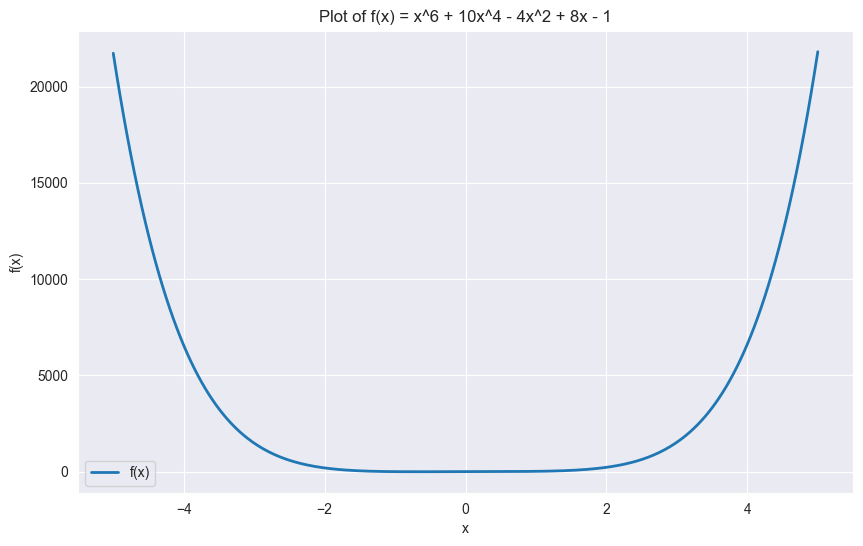

In [47]:
x = np.linspace(-5, 5, 400)
y = func(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label="f(x)", color="C0", linewidth=2)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Plot of f(x) = x^6 + 10x^4 - 4x^2 + 8x - 1")
plt.grid(True)
plt.legend()
plt.show()


In [48]:
def regula_falsi(a: float, b: float, Es: float = 1e-5, max_iter: int = 100)-> dict:
   
    a_list = []
    b_list = []
    c_list = []
    i_list = []
    func_c_list = []

    for i in range(1, max_iter + 1):
        func_a = func(a)
        func_b = func(b)

        if func_b - func_a == 0:
            raise ValueError("Division by zero encountered in regula_falsi formula")

        c = (a * func_b - b * func_a) / (func_b - func_a)
        func_c = func(c)

        # record
        i_list.append(i)
        a_list.append(a)
        b_list.append(b)
        c_list.append(c)
        func_c_list.append(func_c)

        if abs(func_c) < Es or func_c == 0:
            break

        if func_a * func_c < 0:
            b = c
        else:
            a = c

    return {"Iter.": i_list, "a": a_list, "b": b_list, "c": c_list, "func(c)": func_c_list}

In [49]:
def display_table(table: dict) -> None:
    df = pd.DataFrame(table)
    print(df.to_string(index=False))
    print(f"\n---> ROOT = {df['c'].iat[-1]:.6f}")

In [ ]:
def get_input()->tuple:
    while True:
        try:
            print("f(x) = x**6 + 10*x**4 - 4*x**2 + 8*x - 1")
            vals = input("Enter initial guesses separated by space:\n> ").strip().split()
            if len(vals) != 2:
                print("Please enter exactly two numbers.")
                continue
            initialGuess_1, initialGuess_2 = map(float, vals)

            if func(initialGuess_1) * func(initialGuess_2) >= 0:
                print("Product of functional values of initial guesses must be less than zero. Try again.\n")
                continue
            
            return initialGuess_1, initialGuess_2
        except ValueError:
            print("Invalid numbers. Try again.")


In [51]:
def main()-> None:
    a, b = get_input()
    table = regula_falsi(a, b)
    display_table(table)


if __name__ == '__main__':
    main()

f(x) = x**6 + 10*x**4 - 4*x**2 + 8*x - 1
 Iter.         a    b         c   func(c)
     1 -1.000000 -1.2 -1.042726 -0.583845
     2 -1.042726 -1.2 -1.054282 -0.152512
     3 -1.054282 -1.2 -1.057240 -0.038664
     4 -1.057240 -1.2 -1.057985 -0.009727
     5 -1.057985 -1.2 -1.058173 -0.002442
     6 -1.058173 -1.2 -1.058220 -0.000613
     7 -1.058220 -1.2 -1.058232 -0.000154
     8 -1.058232 -1.2 -1.058235 -0.000039
     9 -1.058235 -1.2 -1.058235 -0.000010

---> ROOT = -1.058235
